# LinUCB & Contextual Thompson Sampling

Applies two contextual bandit algorithms to the synthetic SPF scam dataset:
- **LinUCB** — disjoint linear UCB with one-hot arm context augmentation
- **Contextual Thompson Sampling** — Bayesian posterior sampling over linear reward weights

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(4014)

In [51]:
DATA_PATH = '../data/synthetic_spf_scam_cases_1H2025.csv'
df = pd.read_csv(DATA_PATH)
print(f'Rows: {len(df):,}')
df.head()

Rows: 19,665


,case_id,age_group,scam_type,contact_method,source_platform,requires_user_action,payment_method,urgency_level,loss_bucket,transaction_amount,is_scam
0,1,30-49,Job,Classified Ads,Classifieds,1,Card,Medium,2k-5k,3721.57,1
1,2,20-29,Phishing,Classified Ads,Classifieds,1,E-wallet,Medium,2k-5k,2168.36,1
2,3,20-29,Job,Phone Call,Phone,1,E-wallet,High,5k-10k,5811.74,1
3,4,30-49,Phishing,Social Media,Facebook,1,Card,Medium,<2k,187.44,1
4,5,<20,Job,Messaging,WhatsApp,1,E-wallet,Medium,10k-50k,12426.74,1


## Feature engineering

In [52]:
categorical_features = ['age_group', 'scam_type', 'source_platform', 'payment_method', 'urgency_level', 'loss_bucket']

feature_df = pd.get_dummies(df[categorical_features], drop_first=False)
feature_df['requires_user_action'] = df['requires_user_action'].astype(float)
feature_df['log_amount'] = np.log1p(df['transaction_amount'])

feature_matrix = feature_df.to_numpy(dtype=float)
feature_columns = feature_df.columns.tolist()

print(f'Feature matrix shape: {feature_matrix.shape}')
feature_df.head()

Feature matrix shape: (19665, 52)


,age_group_20-29,age_group_30-49,age_group_50-64,age_group_65+,age_group_<20,scam_type_E-commerce,scam_type_Fake Friend Call,scam_type_Government Impersonation,scam_type_Insurance Services,scam_type_Internet Love,...,urgency_level_Low,urgency_level_Medium,loss_bucket_100k+,loss_bucket_10k-50k,loss_bucket_2k-5k,loss_bucket_50k-100k,loss_bucket_5k-10k,loss_bucket_<2k,requires_user_action,log_amount
0,False,True,False,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,1.0,8.222170
1,True,False,False,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,1.0,7.682187
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,1.0,8.667807
3,False,True,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,1.0,5.238780
4,False,False,False,False,True,False,False,False,False,False,...,False,True,False,True,False,False,False,False,1.0,9.427686


## Arm declaration

In [53]:
class InterventionArm:
    def __init__(self, arm_id, name, friction, effectiveness):
        self.arm_id = arm_id
        self.name = name
        self.friction = friction
        self.effectiveness = effectiveness

ARMS = [
    InterventionArm(arm_id=0, name='Self-guided checklist',          friction=0.05, effectiveness=0.20),
    InterventionArm(arm_id=1, name='Digital footprint scan',         friction=0.15, effectiveness=0.50),
    InterventionArm(arm_id=2, name='Redirect to official channels',  friction=0.30, effectiveness=0.70),
    InterventionArm(arm_id=3, name='Schedule transaction',           friction=0.50, effectiveness=0.85),
    InterventionArm(arm_id=4, name='Mandatory bank consultation',    friction=0.80, effectiveness=0.95),
]

n_arms = len(ARMS)
arm_names = [arm.name for arm in ARMS]
n_features = feature_matrix.shape[1]

# Simulated ground-truth reward weights per arm
true_thetas = np.random.normal(0, 1, size=(n_arms, n_features))
true_thetas[3] += 1.5  # Schedule transaction
true_thetas[4] += 2.0  # Mandatory bank consultation

## LinUCB

In [54]:
class LinUCB:
    def __init__(self, n_arms: int, n_features: int, alpha: float):
        self.n_arms = n_arms
        self.n_features = n_features
        self.alpha = alpha
        self.A = [np.identity(n_features) for _ in range(n_arms)]  # The inverse of A can be considered as the covariance of the thetas
        self.b = [np.zeros(n_features) for _ in range(n_arms)]  # Intermediary object to resolve theta; same b as in Algorithm 1 (page 4) of the LinUCB paper

    def update(self, arm: int, context: np.ndarray, reward: float) -> None:
        self.A[arm] += np.outer(context, context)
        self.b[arm] += reward * context

    def recommend(self, context_matrix: np.ndarray):
        scores = np.zeros(self.n_arms)
        thetas = [np.zeros(self.n_features) for _ in range(self.n_arms)]

        for arm in range(self.n_arms):
            A_inv = np.linalg.inv(self.A[arm])
            theta = A_inv @ self.b[arm]
            p_arm = theta.T @ context_matrix[arm] + self.alpha * np.sqrt(context_matrix[arm].T @ A_inv @ context_matrix[arm])
            scores[arm] = p_arm
            thetas[arm] = theta

        return int(np.argmax(scores)), thetas, scores

### Helpers

In [55]:
def augment_context(x, arm, n_arms):
    arm_one_hot = np.zeros(n_arms)
    arm_one_hot[arm] = 1
    return np.concatenate([x, arm_one_hot])

def simulate_one_time_reward(x, true_theta, noise_scale=250.0):
    signal = true_theta @ x
    noise = np.random.normal(scale=noise_scale)
    return signal + noise

class ContextSampler:
    def __init__(self, feature_matrix: np.ndarray):
        self.feature_matrix = feature_matrix
        self.n_samples = feature_matrix.shape[0]

    def sample(self) -> np.ndarray:
        idx = np.random.randint(0, self.n_samples)
        return self.feature_matrix[idx]

### Simulation

In [56]:
n_trials = len(feature_matrix)
alpha = 0.5
augmented_n_features = n_features + n_arms

linucb = LinUCB(n_arms=n_arms, n_features=augmented_n_features, alpha=alpha)

reward_history  = np.zeros(n_trials)
regret_history  = np.zeros(n_trials)
arm_history     = np.zeros(n_trials, dtype=int)
theta_history   = np.zeros((n_trials, n_arms, augmented_n_features))
score_history   = np.zeros((n_trials, n_arms))

indices = np.random.permutation(n_trials)

for t in range(n_trials):
    user_context = feature_matrix[indices[t]]
    context_matrix = np.array([augment_context(user_context, arm, n_arms) for arm in range(n_arms)])

    arm_selected, thetas, scores = linucb.recommend(context_matrix)

    observed_reward = simulate_one_time_reward(user_context, true_thetas[arm_selected])
    optimal_reward  = (true_thetas @ user_context).max()

    linucb.update(arm_selected, context_matrix[arm_selected], observed_reward)

    reward_history[t] = observed_reward
    regret_history[t] = optimal_reward - observed_reward
    arm_history[t]    = arm_selected
    theta_history[t]  = thetas
    score_history[t]  = scores

print(f'Completed {n_trials} LinUCB interactions over {n_arms} arms.')

Completed 19665 LinUCB interactions over 5 arms.


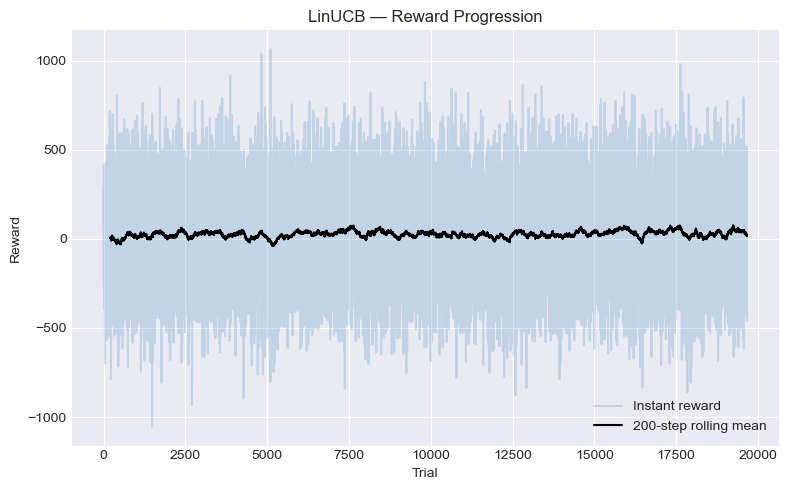

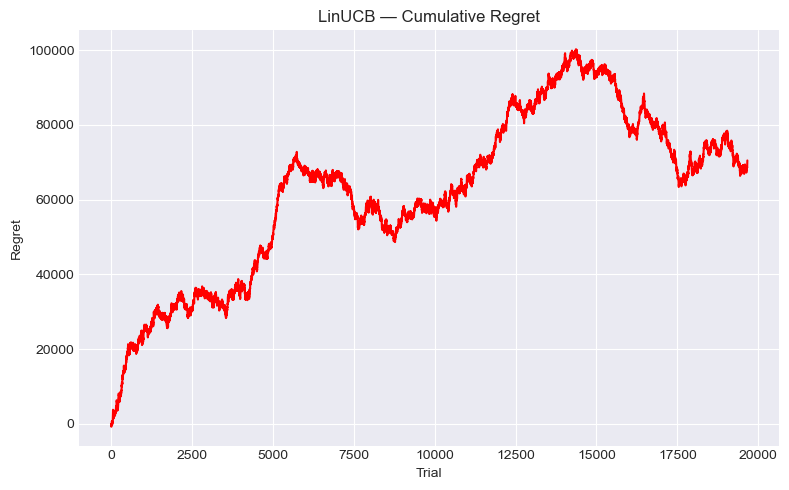

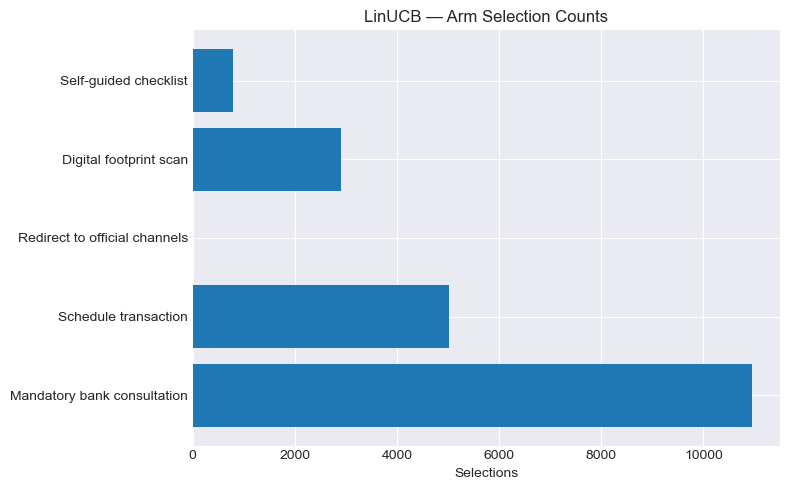

In [57]:
window = 200
rolling_reward = pd.Series(reward_history).rolling(window).mean()

plt.figure(figsize=(8, 5))
plt.plot(reward_history, alpha=0.2, label='Instant reward')
plt.plot(rolling_reward, color='black', label=f'{window}-step rolling mean')
plt.title('LinUCB — Reward Progression')
plt.xlabel('Trial')
plt.ylabel('Reward')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(regret_history), color='red')
plt.title('LinUCB — Cumulative Regret')
plt.xlabel('Trial')
plt.ylabel('Regret')
plt.tight_layout()
plt.show()

arm_counts = pd.Series(arm_history).value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.barh(arm_names, arm_counts.values)
plt.title('LinUCB — Arm Selection Counts')
plt.xlabel('Selections')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Contextual Thompson Sampling

In [58]:
class ContextualThompsonSampling:
    def __init__(self, n_arms: int, context_dim: int, v: float = 1.0):
        self.n_arms = n_arms
        self.context_dim = context_dim
        self.v = v
        self._reset()

    def _reset(self):
        d = self.context_dim
        self.B  = [np.eye(d) for _ in range(self.n_arms)]  # Precision matrix
        self.f  = [np.zeros(d) for _ in range(self.n_arms)]  # Sufficient statistic
        self.mu = [np.zeros(d) for _ in range(self.n_arms)]  # Posterior mean
        self.t = 0
        self.history = []

    def update(self, arm: int, context: np.ndarray, reward: float):
        x = np.asarray(context, dtype=float)
        self.B[arm]  += np.outer(x, x)
        self.f[arm]  += x * reward
        self.mu[arm]  = np.linalg.solve(self.B[arm], self.f[arm])

    def select_arm(self, context: np.ndarray) -> int:
        x = np.asarray(context, dtype=float)
        expected_rewards = []

        for a in range(self.n_arms):
            cov = self.v**2 * np.linalg.inv(self.B[a])
            theta_sample = np.random.multivariate_normal(self.mu[a], cov)
            expected_rewards.append(x @ theta_sample)

        return int(np.argmax(expected_rewards))

    def act_and_learn(self, context: np.ndarray, reward_fn) -> dict:
        self.t += 1
        arm    = self.select_arm(context)
        reward = reward_fn(arm, context)
        self.update(arm, context, reward)
        return {'t': self.t, 'arm': arm, 'reward': reward}

    def posterior_mean(self, arm: int) -> np.ndarray:
        return self.mu[arm].copy()

    def posterior_cov(self, arm: int) -> np.ndarray:
        return self.v**2 * np.linalg.inv(self.B[arm])

### Environment

In [59]:
class Environment:
    def __init__(self, feature_matrix: np.ndarray, arms: list, df: pd.DataFrame):
        self.feature_matrix = feature_matrix
        self.arms = arms
        self.df = df
        self.n_arms = len(arms)
        self.context_dim = feature_matrix.shape[1]
        self.true_theta = np.random.randn(self.n_arms, self.context_dim) * 0.3
        for arm_id in range(self.n_arms):
            self.true_theta[arm_id] *= arms[arm_id].effectiveness

    # R = (Financial benefit) - (Friction penalty) = (S * T * E) - ((1 - S) * A * U)
    def compute_reward(self, arm_id: int, context: np.ndarray, scam_prob: float, transaction_amount: float, urgency: float) -> float:
        arm = self.arms[arm_id]
        linear_term       = context @ self.true_theta[arm_id]
        financial_benefit = scam_prob * (transaction_amount / 10000) * arm.effectiveness
        friction_penalty  = (1 - scam_prob) * arm.friction * urgency
        reward = financial_benefit - friction_penalty
        return float((0.5 * reward) + (0.5 * linear_term) + np.random.normal(0, 0.1))

    def sample_context(self) -> Tuple[np.ndarray, float, float, float]:
        idx     = np.random.randint(0, len(self.feature_matrix))
        context = self.feature_matrix[idx].copy()
        sample  = self.df.iloc[idx]
        scam_prob = float(sample['is_scam'])
        amount    = float(sample['transaction_amount'])
        urgency_map = {'Low': 1, 'Medium': 2, 'High': 3}
        urgency = urgency_map.get(sample['urgency_level'], 2) / 3.0
        return context, scam_prob, amount, urgency

    def optimal_arm(self, context, scam_prob, amount, urgency) -> int:
        rewards = [self.compute_reward(a, context, scam_prob, amount, urgency) for a in range(self.n_arms)]
        return int(np.argmax(rewards))

    def optimal_reward(self, context, scam_prob, amount, urgency) -> float:
        arm = self.optimal_arm(context, scam_prob, amount, urgency)
        return self.compute_reward(arm, context, scam_prob, amount, urgency)

### Simulation

In [60]:
env   = Environment(feature_matrix, ARMS, df)
agent = ContextualThompsonSampling(n_arms=len(ARMS), context_dim=feature_matrix.shape[1], v=1.0)

In [61]:
N_SIMULATIONS = 100
N_TIMESTEPS   = 1000

ts_all_rewards  = []
ts_all_regrets  = []
ts_all_arms     = []
ts_arm_counts   = np.zeros(len(ARMS))

for sim in range(N_SIMULATIONS):
    agent._reset()
    sim_rewards, sim_regrets, sim_arms = [], [], []

    for t in range(N_TIMESTEPS):
        context, scam_prob, amount, urgency = env.sample_context()

        def reward_fn(arm, ctx):
            return env.compute_reward(arm, ctx, scam_prob, amount, urgency)

        info   = agent.act_and_learn(context, reward_fn)
        opt_r  = env.optimal_reward(context, scam_prob, amount, urgency)
        regret = opt_r - info['reward']

        sim_rewards.append(info['reward'])
        sim_regrets.append(regret)
        sim_arms.append(info['arm'])

    ts_all_rewards.append(np.array(sim_rewards))
    ts_all_regrets.append(np.array(sim_regrets))
    ts_all_arms.append(np.array(sim_arms))
    ts_arm_counts += np.bincount(sim_arms, minlength=len(ARMS))

LinAlgError: SVD did not converge

In [ ]:
ts_rewards_mean = np.array(ts_all_rewards).mean(axis=0)
ts_regrets_mean = np.array(ts_all_regrets).mean(axis=0)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(ts_rewards_mean, color='blue', linewidth=1.5, label='Mean reward')
plt.title('Contextual Thompson Sampling — Average Reward per Timestep')
plt.xlabel('Timestep')
plt.ylabel('Reward')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(ts_regrets_mean, color='red', linewidth=1.5, label='Mean regret')
plt.title('Contextual Thompson Sampling — Average Regret per Timestep')
plt.xlabel('Timestep')
plt.ylabel('Regret')
plt.legend()
plt.tight_layout()
plt.show()

sorted_idx    = np.argsort(ts_arm_counts)[::-1]
sorted_names  = [arm_names[i] for i in sorted_idx]
sorted_counts = ts_arm_counts[sorted_idx]

plt.figure(figsize=(10, 6))
bars = plt.bar(sorted_names, sorted_counts, color='teal', alpha=0.8, edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + sorted_counts.max()*0.01, int(yval), ha='center', va='bottom', fontsize=10)
plt.title('Contextual Thompson Sampling — Arm Selection Frequency')
plt.ylabel('Times selected')
plt.xlabel('Intervention arm')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()